**Importing**

In [8]:
from util import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

**Linear regression**

In [9]:
# Data generation
np.random.seed(2025)

n_points = 50

noise = 0.01 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise


In [10]:

maxdegree = 15
mses = []
mses_test = []
r2s = []
r2s_test = []
degrees = list(range(2, maxdegree+1))
betas = []

for degree in degrees:
    X = PolynomialFeatures(degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    
    beta = OLS(X_train, y_train)
    betas.append(beta)
    predictions_train = X_train @ beta
    predictions_test = X_test @ beta

    # Compute MSE
    mses.append(mean_squared_error(y_train, predictions_train))
    mses_test.append(mean_squared_error(y_test, predictions_test))

    # Compute R2
    r2s.append(r2_score(y_train, predictions_train))
    r2s_test.append(r2_score(y_test, predictions_test))

**Plotting**

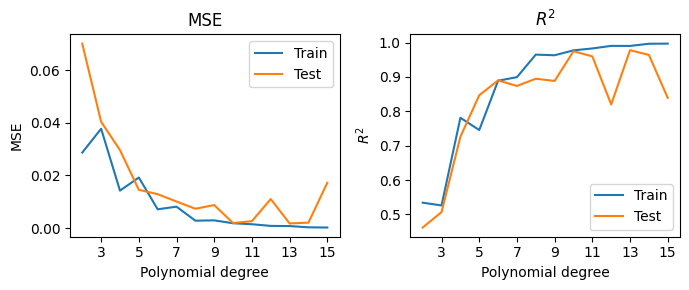

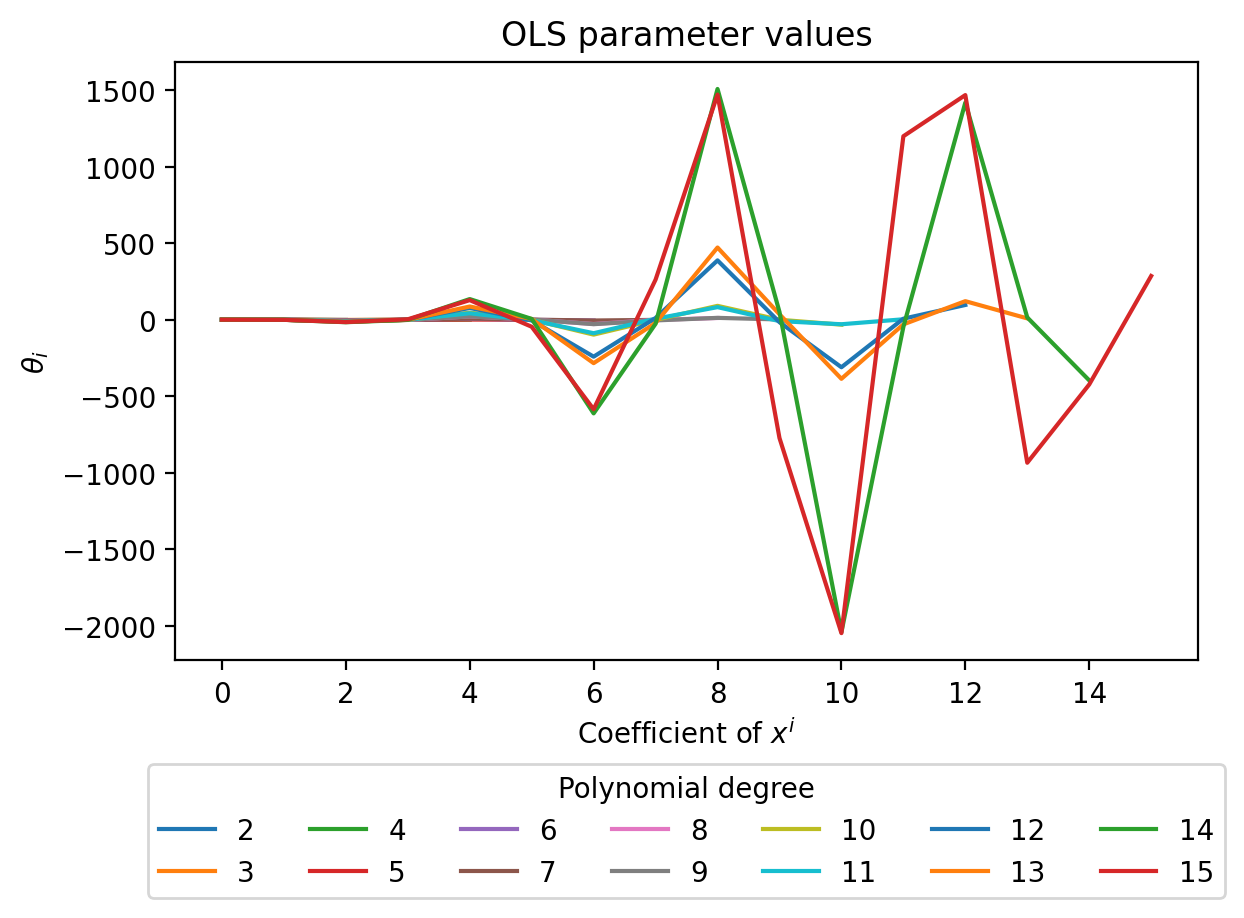

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (7, 3)) 

# Plotting MSE
ax = axes[0]
ax.plot(degrees, mses, label = "Train")
ax.plot(degrees,mses_test, label = "Test")
ax.legend()
ax.set_xticks(degrees[1::2])
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("MSE")

# Plotting R^2
ax = axes[1]
ax.plot(degrees, r2s, label = "Train")
ax.plot(degrees,r2s_test, label = "Test")
ax.legend()
ax.set_xticks(degrees[1::2])
ax.set_xlabel("Polynomial degree")
ax.set_ylabel(r"$R^2$")
ax.set_title(r"$R^2$")
fig.tight_layout()

plt.figure()
for degree, beta in zip(degrees, betas):
    plt.plot(range(degree+1), beta, label = str(degree))
plt.title(r"OLS parameter values")
plt.xlabel(r"Coefficient of $x^i$")
plt.ylabel(r"$\theta_i$")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=len(betas)//2, title = "Polynomial degree")
plt.tight_layout()

### Noise effect on model

In [12]:
np.random.seed(2025)

n_points = 100

noise = np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y_noiseless = Runge(x)
poly_degree = 10

X = PolynomialFeatures(degree = poly_degree).fit_transform(x)

noise_levels = np.insert(np.logspace(-2, 2, 5),0 ,0)
mses = []
r2s = []
for noise_level in noise_levels:
    y = y_noiseless + noise_level * noise
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    beta = OLS(X_train, y_train)
    predictions_test = X_test @ beta

    mses.append(mean_squared_error(y_test, predictions_test))
    r2s.append(r2_score(y_test, predictions_test))

for noise_level, mse, r2 in zip(noise_levels, mses, r2s):
    print(f"Noise level: {noise_level:.4f}, MSE: {mse:.4f}, R^2: {r2:.4f}")

Noise level: 0.0000, MSE: 0.0020, R^2: 0.9720
Noise level: 0.0100, MSE: 0.0017, R^2: 0.9719
Noise level: 0.1000, MSE: 0.0121, R^2: 0.8860
Noise level: 1.0000, MSE: 1.1143, R^2: -0.3218
Noise level: 10.0000, MSE: 72.8206, R^2: -0.1491
Noise level: 100.0000, MSE: 8490.5448, R^2: -0.0652
